In [21]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations, permutations

def euclid_distance(p1: np.ndarray, p2: np.ndarray) -> float:
    """
    takes two points p1, p2 as two ndarrays of length d (d: dimension) 
    and calculates the euclidean distance between the two points
    returns distance as float value
    """
    return np.sqrt(np.sum(np.square(p1 - p2)))

def tsp_length(nodes_array: np.ndarray) -> float:
    """
    calculate the length of the tsp traveling distance
    
    :param nodes_array: (sorted) array of coordinates of the N nodes
    :type nodes_array: np.ndarray (N, d)
    :return: total traveling distance
    :rtype: float
    """
    # calculate the pairwise differences between two consecutive nodes, keep in mind to return to start
    differences = nodes_array - np.roll(nodes_array, shift=-1, axis=0)
    # calculate individual distances and sum up
    distances = np.sqrt(np.sum(np.square(differences), axis=1))
    return np.sum(distances)

def polar_to_cartesian(r: float, theta: float) -> np.ndarray:
    """
    convert polar coordinates to cartesian coordinates
    
    :param r: radius
    :type r: float
    :param theta: angle in radians
    :type theta: float
    :return: cartesian coordinates as ndarray [x, y]
    :rtype: np.ndarray
    """
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return np.column_stack([x, y])

def cartesian_to_polar(x: float, y: float) -> np.ndarray:
    """
    convert cartesian coordinates to polar coordinates
    
    :param x: x coordinate
    :type x: float
    :param y: y coordinate
    :type y: float
    :return: polar coordinates as ndarray [r, theta]
    :rtype: np.ndarray
    """
    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)
    return np.column_stack([r, theta])

def tsp_length_from_dist_matrix(distance_matrix: np.ndarray, permutation: np.ndarray) -> float:
    """
    calculate the length of the tsp traveling distance
    given the distance matrix D and the current permutation
    
    :param distance_matrix: 2d array of distances of the node i to node j,
    (note D_{i,j}^T = D_{j,i} = D_{i,j} and D_{i,i} = 0 ∀i)
    :type distance_matrix: np.ndarray (N, N)
    :param permutation: 1d array of current permutation given as set of not repeating indices
    :type permutation: np.ndarray (N)
    :return: total traveling distance
    :rtype: float
    """
    # sum distances between consecutive nodes (equation 3 in Cerny 1985)
    d = np.sum(distance_matrix[permutation[:-1], permutation[1:]])
    # add distance from last node back to first
    d += distance_matrix[permutation[-1], permutation[0]]
    return d

def metric_time_dep(
    node_coordinates: np.ndarray,
    distance_matrix: np.ndarray,
    permutation: np.ndarray,
    f: float = 0.5,
    M: int = 5,
    traffic_jam_area: np.ndarray = None,
) -> float:
    """
    time dependent metric for the traveling salesman problem
    with traffic jam areas

    :param node_coordinates: array of coordinates of the N nodes
    :type node_coordinates: np.ndarray (N, d)

    :param distance_matrix: 2d array of distances of the node i to node j,
    (note D_{i,j}^T = D_{j,i} = D_{i,j} and D_{i,i} = 0 ∀i)
    :type distance_matrix: np.ndarray (N, N)

    :param permutation: 1d array of current permutation given as set of not repeating indices
    :type permutation: np.ndarray (N)

    :param f: decrease in speed factor within the traffic jam area
    :type f: float

    :param M: starting time of the traffic jam (additional distance factor)
    :type M: int

    :param traffic_jam_area: area of the traffic jam defined by [[xmin, xmax], [ymin, ymax]]
    :type traffic_jam_area: np.ndarray (2, 2)

    :return: total traveling distance
    :rtype: float
    """

    if traffic_jam_area is None:
        traffic_jam_area = np.array([[0, 1], [0, 1]])

    def eta(i: int) -> int:
        """determine if node i and node i + 1 are within the traffic jam area"""
        x1, y1 = node_coordinates[permutation[i]]
        x2, y2 = node_coordinates[permutation[(i + 1) % len(permutation)]]

        inside1 = (traffic_jam_area[0, 0] <= x1 <= traffic_jam_area[0, 1]) and \
                  (traffic_jam_area[1, 0] <= y1 <= traffic_jam_area[1, 1])
        inside2 = (traffic_jam_area[0, 0] <= x2 <= traffic_jam_area[0, 1]) and \
                  (traffic_jam_area[1, 0] <= y2 <= traffic_jam_area[1, 1])

        return int(inside1 and inside2)

    def xi(i: int) -> float:
        """calculate the inner Heaviside helper function xi"""
        s = 0.0
        for j in range(i):
            s += distance_matrix[permutation[j],
                                 permutation[(j + 1) % len(permutation)]]
        return s - M

    def correction_term(i: int) -> float:
        """calculate traffic jam correction term"""
        denom = distance_matrix[permutation[i],
                                permutation[(i + 1) % len(permutation)]]
        if denom == 0:
            return 0.0  # avoid division by zero

        return (
            np.heaviside(xi(i), 1)
            * (1 - np.heaviside(xi(i - 1), 1))
            * xi(i)
            / denom
        )

    # calculate the metric
    distance = 0.0
    n = len(permutation)

    for i in range(n):
        base = distance_matrix[permutation[i],
                               permutation[(i + 1) % n]]

        distance += base * (
            1
            + eta(i)
            * (f - 1)
            * (np.heaviside(xi(i - 1), 1) + correction_term(i))
        )

    return float(distance)

def metric_time_dep_vectorized(
    node_coordinates: np.ndarray,
    distance_matrix: np.ndarray,
    permutation: np.ndarray,
    f: float = 0.5,
    M: float = 5.0,
    traffic_jam_area: np.ndarray = np.array([[0, 1], [0, 1]]),
) -> float:
    """
    time dependent metric for the traveling salesman problem
    with traffic jam areas

    :param node_coordinates: array of coordinates of the N nodes
    :type node_coordinates: np.ndarray (N, d)

    :param distance_matrix: 2d array of distances of the node i to node j,
    (note D_{i,j}^T = D_{j,i} = D_{i,j} and D_{i,i} = 0 ∀i)
    :type distance_matrix: np.ndarray (N, N)

    :param permutation: 1d array of current permutation given as set of not repeating indices
    :type permutation: np.ndarray (N)

    :param f: decrease in speed factor within the traffic jam area
    :type f: float

    :param M: starting time of the traffic jam (additional distance factor)
    :type M: int

    :param traffic_jam_area: area of the traffic jam defined by [[xmin, xmax], [ymin, ymax]]
    :type traffic_jam_area: np.ndarray (2, 2)

    :return: total traveling distance
    :rtype: float
    """
        
    n = len(permutation)

    # --- 1. tour edges (i -> i+1) ---
    i_idx = permutation
    j_idx = permutation[np.roll(np.arange(n), +1)]

    edge_distances = distance_matrix[i_idx, j_idx]   # shape (n,)

    # --- 2. eta(i): both nodes in jam area ---
    coords_i = node_coordinates[i_idx]
    coords_j = node_coordinates[j_idx]

    in_area_i = (
        (traffic_jam_area[0, 0] <= coords_i[:, 0]) &
        (coords_i[:, 0] <= traffic_jam_area[0, 1]) &
        (traffic_jam_area[1, 0] <= coords_i[:, 1]) &
        (coords_i[:, 1] <= traffic_jam_area[1, 1])
    )

    in_area_j = (
        (traffic_jam_area[0, 0] <= coords_j[:, 0]) &
        (coords_j[:, 0] <= traffic_jam_area[0, 1]) &
        (traffic_jam_area[1, 0] <= coords_j[:, 1]) &
        (coords_j[:, 1] <= traffic_jam_area[1, 1])
    )

    eta = in_area_i & in_area_j
    eta = eta.astype(float)

    # --- 3. cumulative distance Xi(i) ---
    # Xi(i) = total distance traveled before edge i minus M
    cumulative_dist = np.cumsum(edge_distances)
    xi = cumulative_dist - M

    # shift version for xi(i-1)
    xi_prev = np.roll(xi, 1)

    # --- 4. Heaviside ---
    H_xi = np.heaviside(xi, 1)
    H_prev = np.heaviside(xi_prev, 1)

    # --- 5. Correction term ---
    # avoid divide-by-zero
    denom = np.where(edge_distances == 0, 1e-12, edge_distances)

    correction = H_xi * (1 - H_prev) * xi / denom

    # --- 6. Final time-dependent metric ---
    distance = np.sum(
        edge_distances
        * (
            1
            + eta * (f - 1) * (H_prev + correction)
        )
    )

    return float(distance)



In [22]:
# define N nodes, uniformly spaced around a circle
N = 8
R = 1
phi = np.array([2 * np.pi * i / N for i in range(0,N)])

nodes = polar_to_cartesian(R, phi)

# brute force TSP solution
# always start and end at node 0
# get all permutations of the nodes excluding the first one
node_indices = np.arange(N)
perms = permutations(node_indices)
tours = nodes[np.array([[0] + list(p) + [0] for p in perms])]
lengths = np.array([tsp_length(tour) for tour in tours])
min_index = np.argmin(lengths)
min_length = lengths[min_index]

print(f"Minimum traveling distance: {min_length:4f}")



Minimum traveling distance: 6.122935


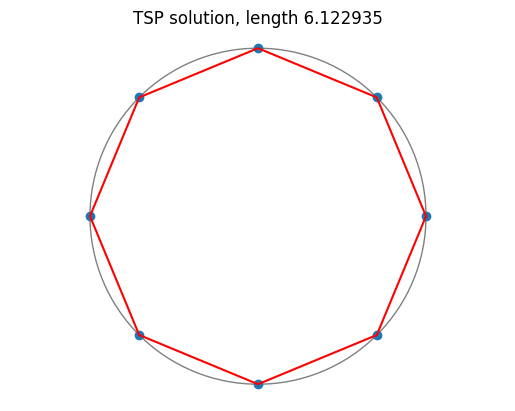

In [23]:
# plot results
plt.figure()
plt.title(f"TSP solution, length {min_length:4f}")

plt.axis('equal')
plt.axis('off')
plt.grid(False)

circle = plt.Circle((0, 0), R, color='gray', fill=False)
plt.gca().add_artist(circle)
plt.scatter(nodes[:, 0], nodes[:,1])
plt.plot(tours[min_index][:, 0], tours[min_index][:, 1], 'r-')
plt.show()

want_a_lot_of_plots = False
if want_a_lot_of_plots:
    for tour in tours[::]:
        plt.figure()
        plt.axis('equal')
        plt.axis('off')
        plt.grid(False)

        circle = plt.Circle((0, 0), R, color='gray', fill=False)
        plt.gca().add_artist(circle)
        plt.scatter(nodes[:, 0], nodes[:,1])
        plt.plot(tour[:, 0], tour[:, 1], 'b-', alpha=0.1)
    plt.show()

## Monte-Carlo simulating an approximative TSP result

In [50]:
# implement algorithm
def simulated_annealing(nodes : np.ndarray, temperatures = [0.1, 0.05, 0.01, 0.001], repetitions = 10000, want_plot=True) -> None:
    """
    simulated annealing algorithm for the stationary traveling salesman problem

    :param nodes: array of coordinates of the N nodes
    :type nodes: np.ndarray (N, d)

    :param temperatures: list of decreasing temperatures for the annealing 
    :type temperatures: list of float

    :param repetitions: number of repetitions per temperature
    :type repetitions: int

    :param want_plots: want a graphical output of the plots
    :type want_plots: boolean
    
    :return: None
    """

    N = len(nodes)

    # calculate the distance matrix D_{i,j} once
    # D_{i,j} denotes the distance of node i to node j (note D_{i,j}^T = D_{j,i} = D_{i,j} and D_{i,i} = 0 ∀i)
    # nodes shape: (N, 2)
    differences = nodes[:, np.newaxis, :] - nodes[np.newaxis, :, :]  # shape: (N, N, 2)
    D = np.sqrt(np.sum(differences**2, axis=-1))                     # shape: (N, N)

    # randomly generate starting permutation
    starting_perm = np.random.permutation(N)
    # print(starting_perm, min(starting_perm), max(starting_perm))

    length_arr = []

    current_perm = starting_perm.copy()
    current_length = tsp_length_from_dist_matrix(D, current_perm)

    temperature_step = 0  # for loading bar
    for temperature in temperatures:
        for repetition in range(repetitions):
            for i in range(N):
                # sample j from 0 to N-1 with j=!i
                choices = np.arange(N)
                j = np.random.choice(choices[choices != i])

                # generate new permutation
                i_tilde, j_tilde = min(i,j), max(i,j)
                trial_perm = current_perm.copy()
                trial_perm[i_tilde : j_tilde + 1] = current_perm[i_tilde : j_tilde + 1][::-1]
                trial_perm[j_tilde + 1 :] = current_perm[j_tilde + 1 :]
                # calculate corresponding length
                trial_length = tsp_length_from_dist_matrix(D, trial_perm)

                length_arr.append(trial_length)

                # accept reject step
                if trial_length < current_length:
                    current_perm = trial_perm.copy()
                    current_length = trial_length
                else:
                    x = np.random.rand()
                    if x < np.exp((current_length - trial_length) / temperature):
                        current_perm = trial_perm.copy()
                        current_length = trial_length 
                
            # loading bar
            fraction = (temperature_step * repetitions + repetition) / (len(temperatures) * repetitions)
            bar_length = 40
            filled_length = int(bar_length * fraction)
            bar = '=' * filled_length + '-' * (bar_length - filled_length)
            print(f'\rAnnealing progress: |{bar}| {fraction:.2%} Complete (T={temperature})', end='', flush=True)           
        temperature_step += 1
    
    if want_plot:
        # plot the tour
        plt.figure(figsize=(12,12))
        plt.title(f"TSP solution, length {current_length:4f}")

        plt.axis('equal')
        plt.axis('off')
        plt.grid(False)

        # circle = plt.Circle((0, 0), R, color='gray', fill=False)
        # plt.gca().add_artist(circle)
        plt.scatter(nodes[:, 0], nodes[:,1], color='black')
        tour = np.append(current_perm, current_perm[0])  # close tour
        plt.plot(nodes[tour, 0], nodes[tour, 1], color='red')
        plt.savefig('simulated_annealing_final_tour.pdf')
        plt.show()

        print(current_perm)

        # plot the convergence
        plt.figure(figsize=(12,12))
        plt.title(f"TSP convergence")
        plt.plot([0, len(length_arr)], [2 * np.pi, 2 * np.pi], '--', alpha = 0.4, color='grey', label=r'2\pi')
        for i in range(1, len(temperatures)):
            plt.plot([i * N * repetitions, i * N * repetitions], [0, max(length_arr)], alpha = 0.4, color='grey')
        plt.plot(length_arr, color='black', label='TSP Length')
        plt.xlim(0.5*len(length_arr), len(length_arr))

        plt.xlabel('Iteration')
        plt.ylabel('TSP Length')
        plt.legend()
        plt.savefig('tsp_sim_annealing_convergence.pdf')
        plt.show()

Annealing progress: |=======================================-| 99.98% Complete (T=0.001)

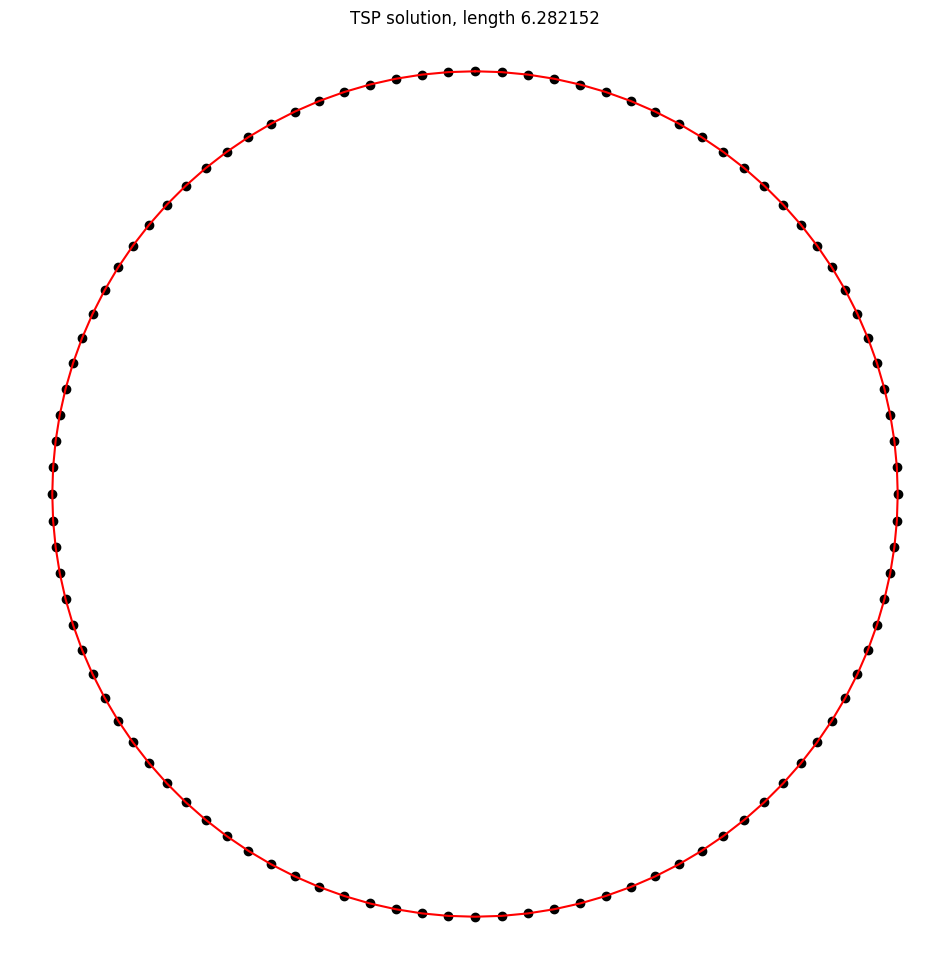

[25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96
 97 98 99  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20
 21 22 23 24]


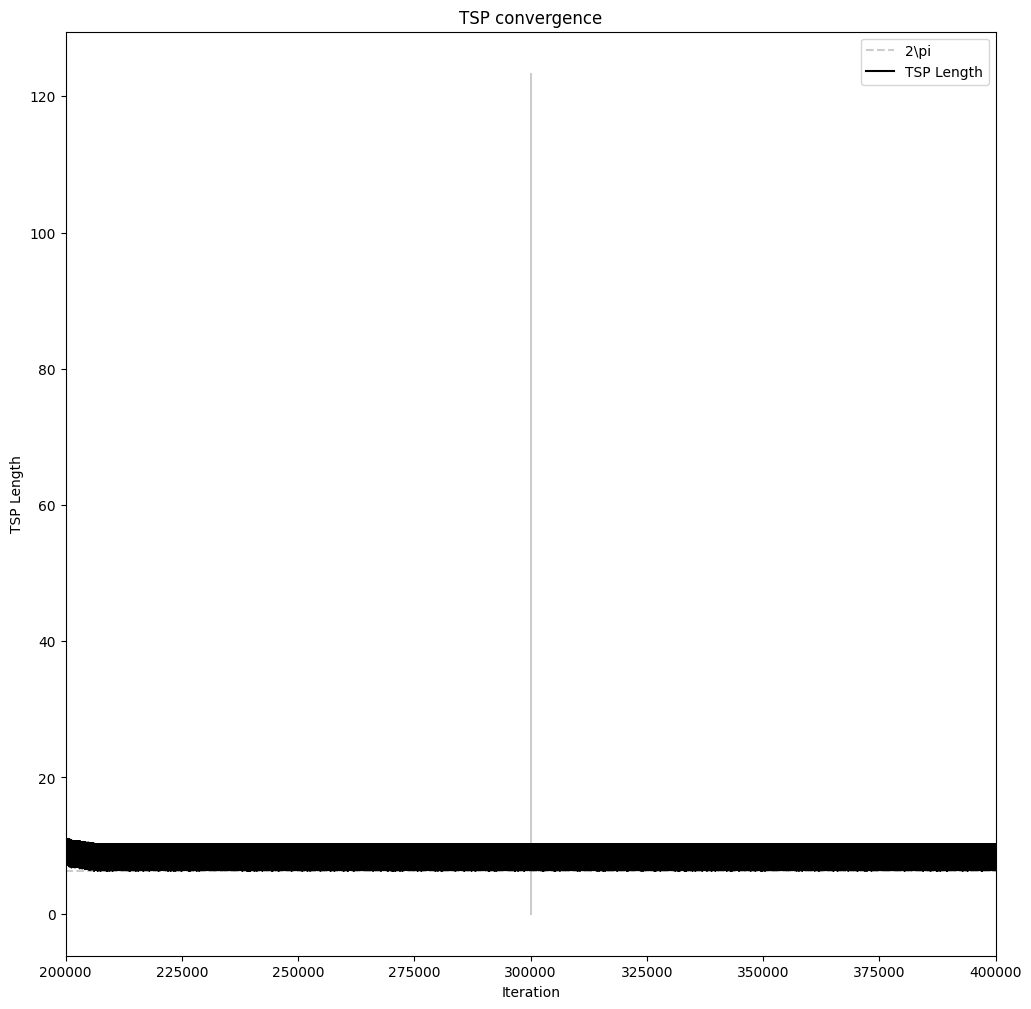

In [51]:
# generating points
# define N nodes, uniformly spaced around a circle
N = 100
R = 1
phi = np.array([2 * np.pi * i / N for i in range(0,N)])

nodes = polar_to_cartesian(R, phi)

simulated_annealing(nodes=nodes, repetitions=1000)

Annealing progress: |=======================================-| 99.97% Complete (T=0.001)

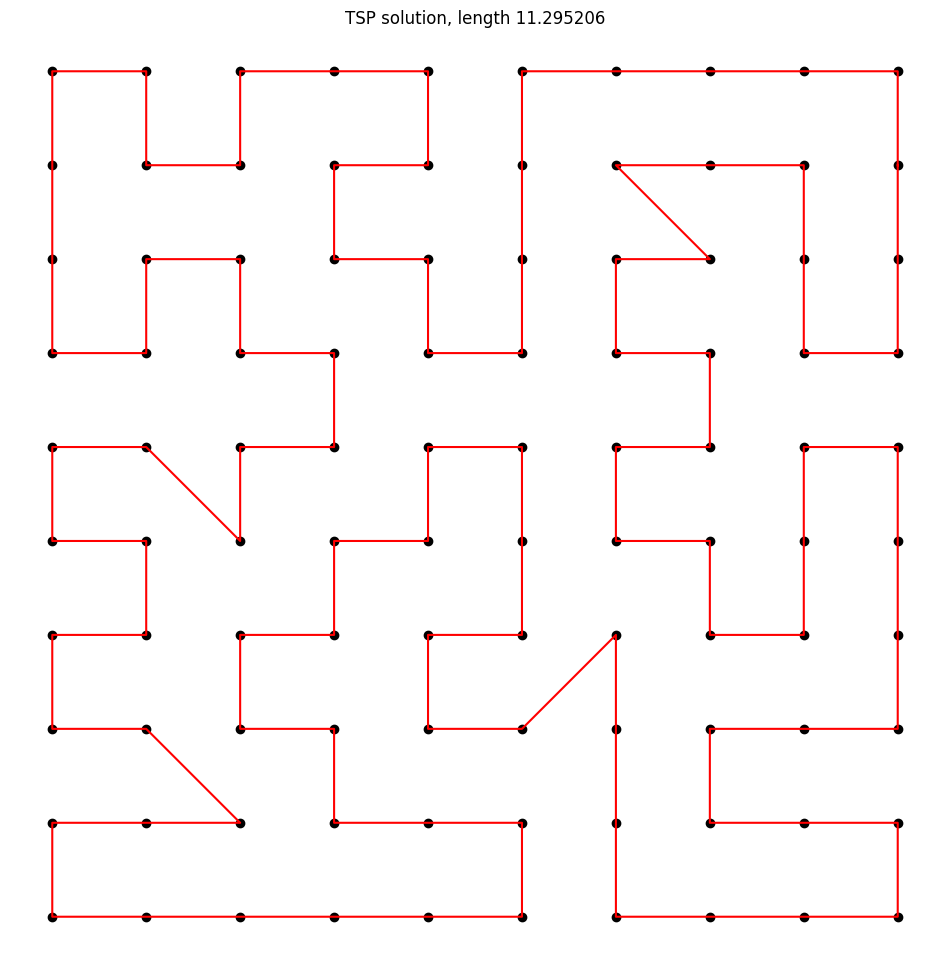

[89 79 69 68 78 88 87 86 77 76 66 67 57 56 46 47 37 38 48 58 59 49 39 29
 28 27 17 18 19  9  8  7  6 16 26 36 25 24 34 35 45 55 54 44 43 33 32 22
 23 13 14 15  5  4  3  2  1  0 10 11 12 21 20 30 31 41 40 50 51 42 52 53
 63 62 72 71 61 60 70 80 90 91 81 82 92 93 94 84 83 73 74 64 65 75 85 95
 96 97 98 99]


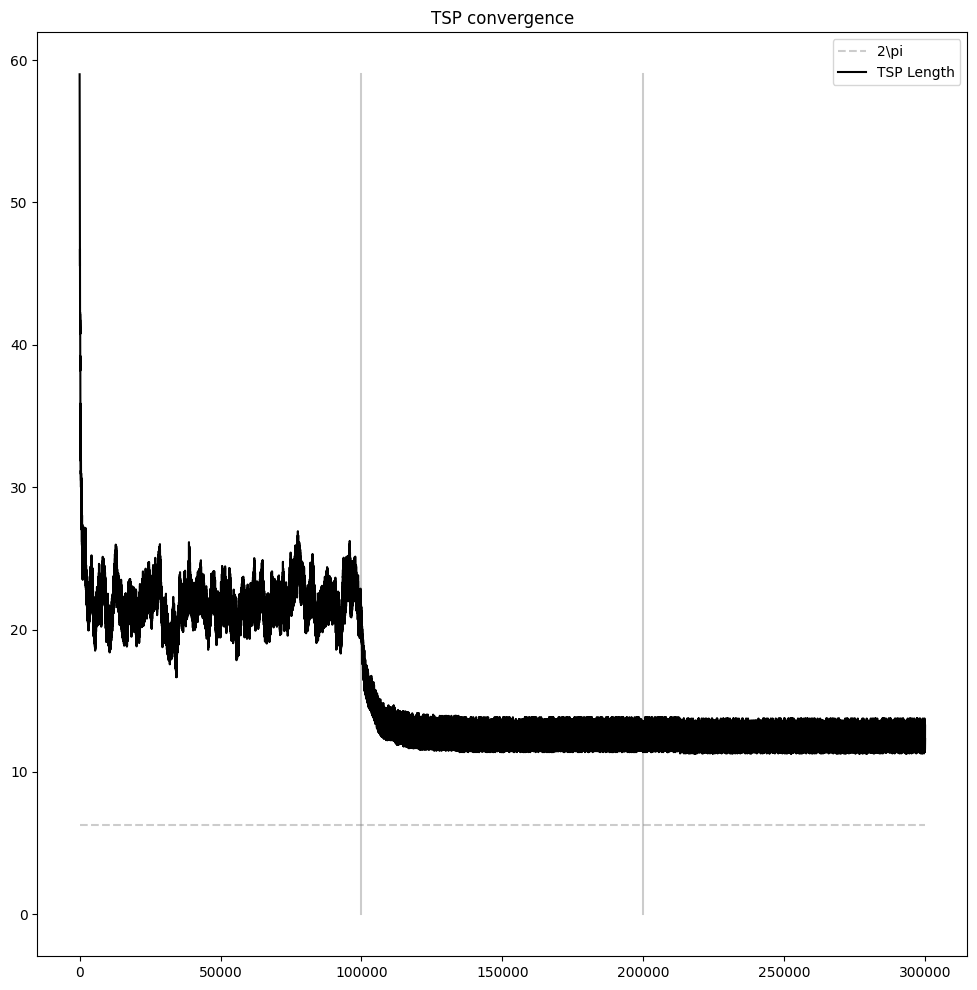

Annealing progress: |=======================================-| 99.97% Complete (T=0.001)

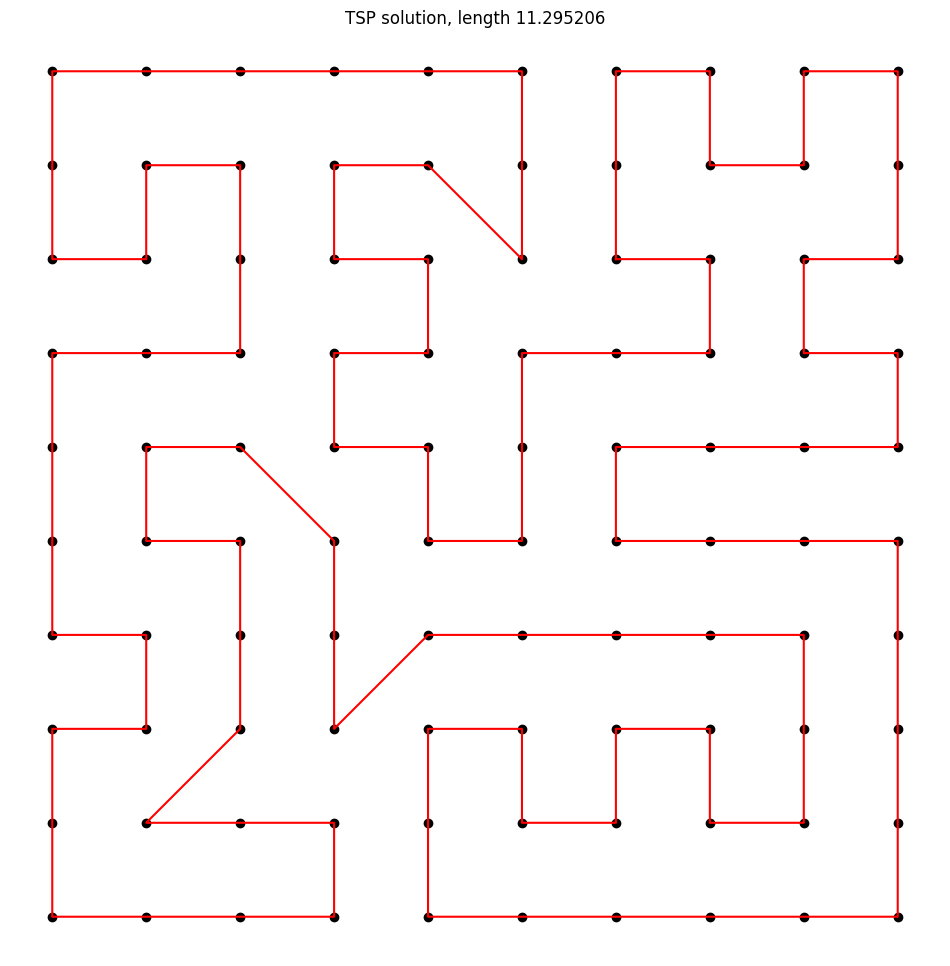

[76 86 96 97 87 88 98 99 89 79 78 68 69 59 58 57 56 46 47 48 49 39 29 19
  9  8  7  6  5  4 14 24 25 15 16 26 27 17 18 28 38 37 36 35 34 23 33 43
 52 51 41 42 32 22 11 12 13  3  2  1  0 10 20 21 31 30 40 50 60 61 62 72
 82 81 71 70 80 90 91 92 93 94 95 85 75 84 83 73 74 64 63 53 54 44 45 55
 65 66 67 77]


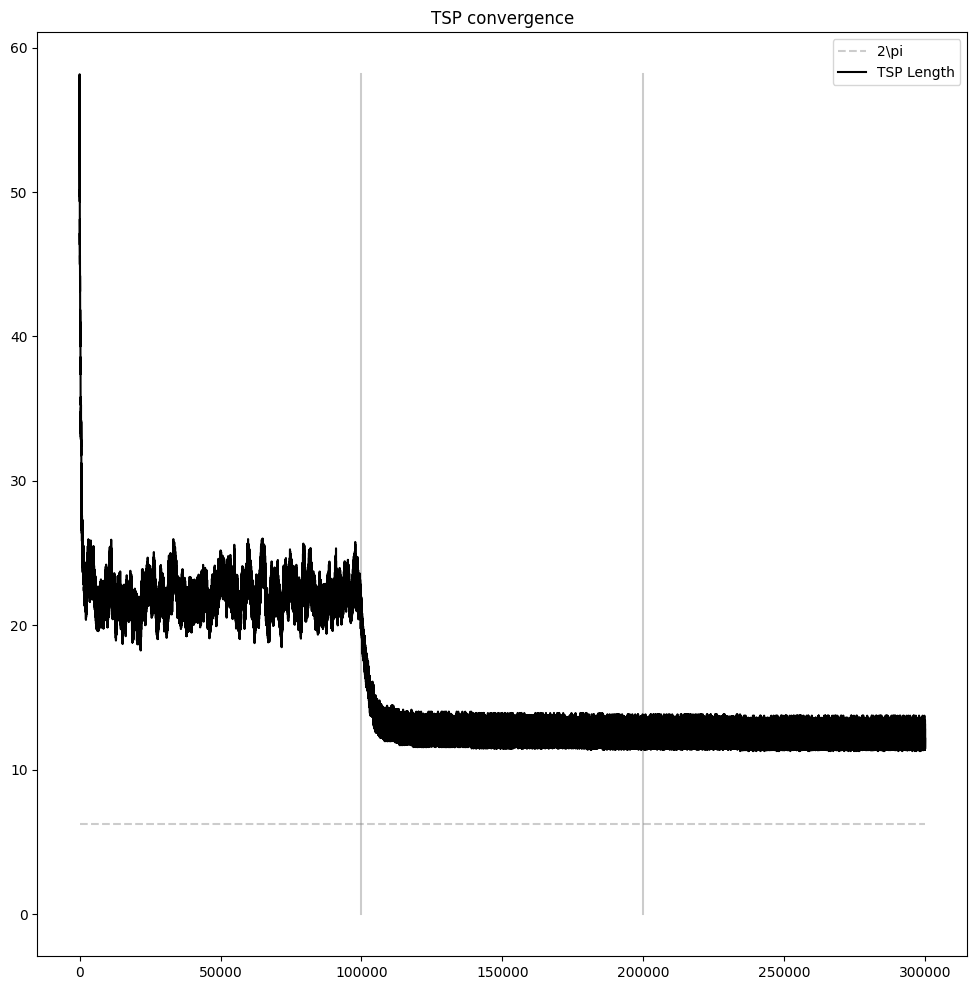

In [31]:
# second example 
# N points aranged on a grid
sqrt_N = 10
N = np.square(sqrt_N)

x = np.linspace(0, 1, sqrt_N)
y = np.linspace(0, 1, sqrt_N)
X, Y = np.meshgrid(x, y)
nodes = np.column_stack([X.flatten(), Y.flatten()])
simulated_annealing(nodes=nodes, repetitions=1000)
simulated_annealing(nodes=nodes, repetitions=1000)


Annealing progress: |=======================================-| 100.00% Complete (T=0.001)

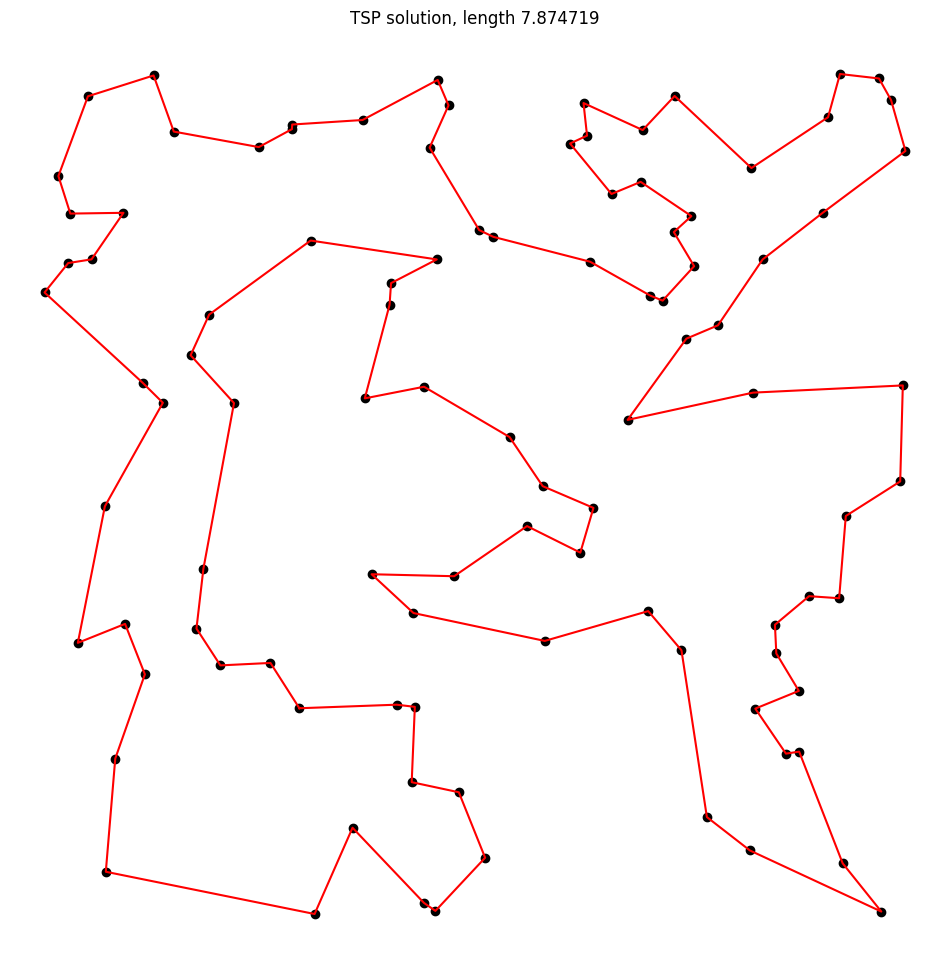

[10 88 72 28 24 64 66 85  8 43 70 11  5 82 35 95 98 76 36 81  0 75 27  7
 30 48 41 87 25 53 39 23 56 67 93 83 94 91 26 21 78 51 52 15 80 14 40 69
 65 31 73 79 89 16 38 50 77 86 84 19 45 47 99 59 62 46 42 54 18 58 32 13
  3 49  1  9  6 60 92 17  4 55 90 20 61 74  2 96 44 29 97 63 68 34 22 37
 71 57 12 33]


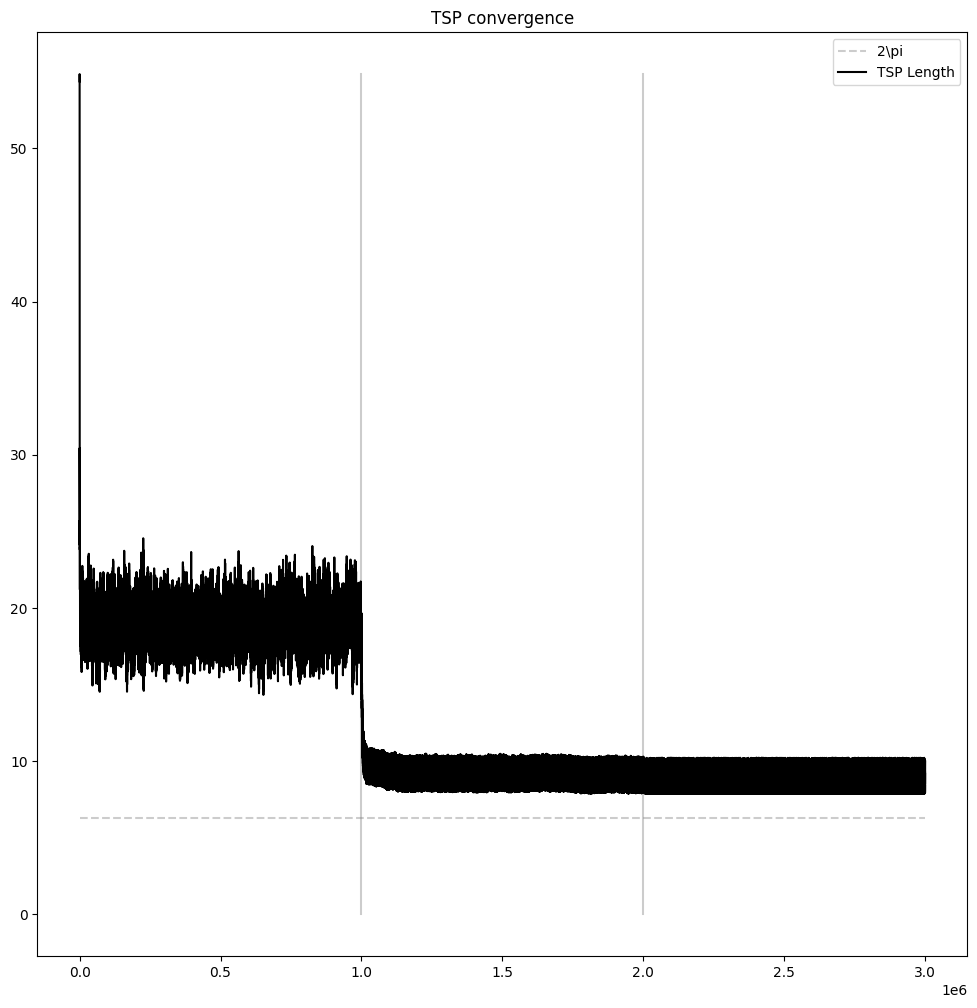

In [27]:
# third example
# N random points in a unit square
N = 100
x = np.random.rand(N)
y = np.random.rand(N)
nodes = np.column_stack([x, y])
simulated_annealing(nodes=nodes)

Annealing progress: |=======================================-| 100.00% Complete (T=0.001)

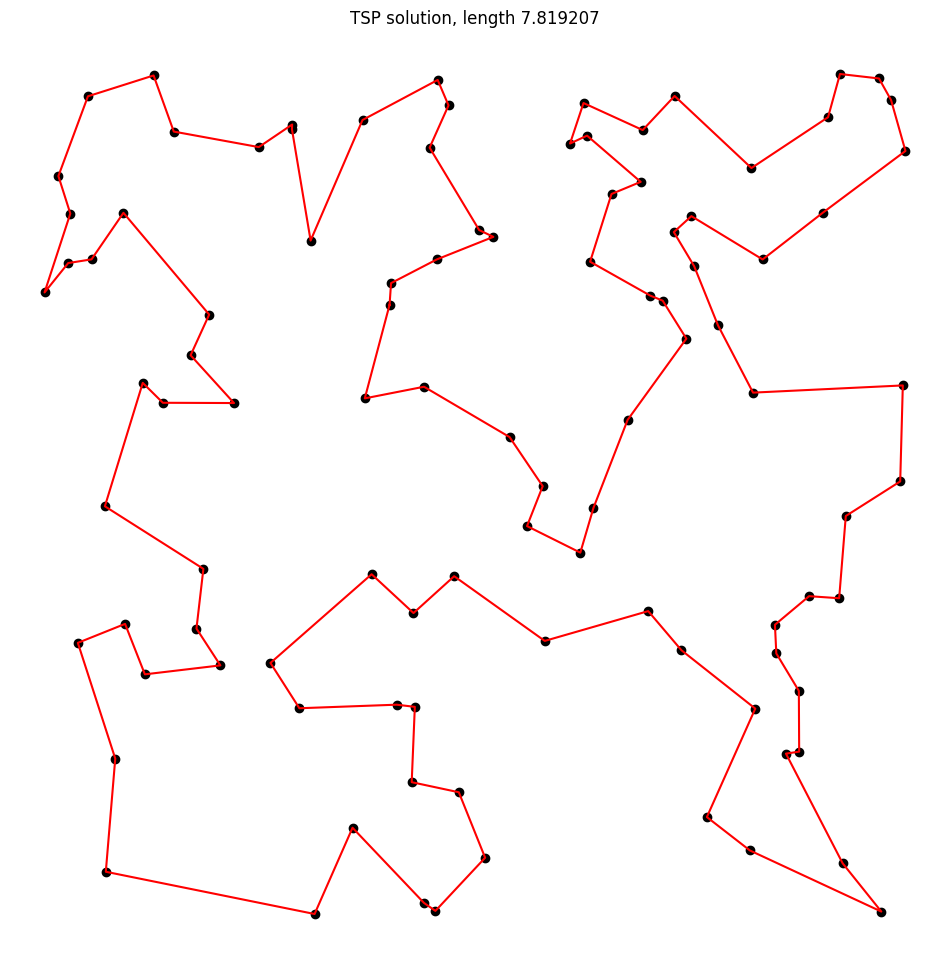

[29 97 63 83 93 67 56 23 39 68 25 53 87 41 48 30  7 27 36 81  0 75 34 22
 37 98 76 95 71 57 12  5 82 35 11 70 43  8 85 66 64 24 28 72 88 10 33  4
 17 55 92 60  6 58  9  1 49  3 32 13 18 54 42 46 62 59 99 47 45 86 21 78
 51 77 50 38 16 89 79 73 31 65 69 40 80 14 52 15 94 91 26 84 19 61 20 90
 74  2 96 44]


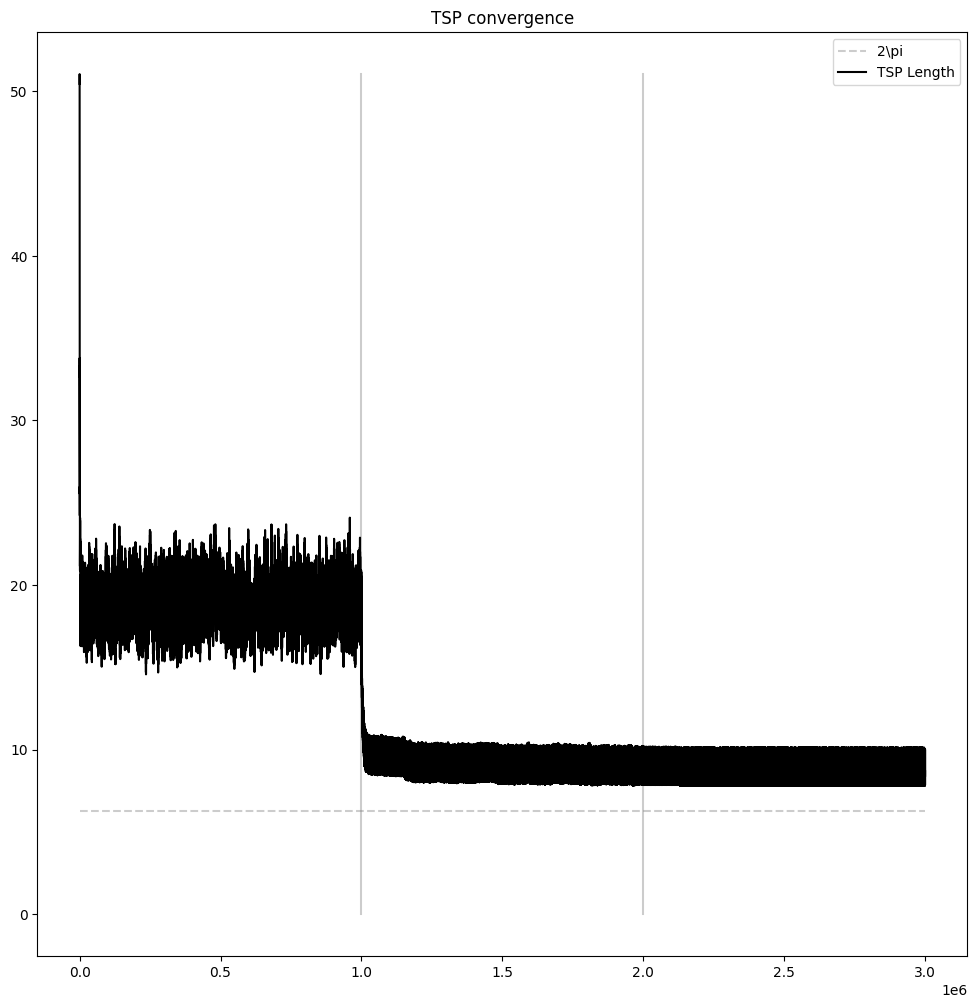

In [30]:
simulated_annealing(nodes=nodes)

## Time-Dependent Simulated Annealing
stationary tsp -> time-dependent tsp:
change metric to include traffic jam area where the ts is slow after time step $M$

In [36]:
# implement time-dependent algorithm
def simulated_annealing_time_dependent(
        nodes : np.ndarray, 
        temperatures = [0.1, 0.01, 0.001], 
        repetitions = 10000, 
        want_plot=True,
        f : float = 0.5, 
        M : int = 5, 
        traffic_jam_area : np.ndarray = np.array([[xmin:=0.25, xmax:=0.75], [ymin:=0.25, ymax:=0.75]])
        ) -> None:
    """
    simulated annealing algorithm for the time-dependent traveling salesman problem

    :param nodes: array of coordinates of the N nodes
    :type nodes: np.ndarray (N, d)

    :param temperatures: list of decreasing temperatures for the annealing 
    :type temperatures: list of float

    :param repetitions: number of repetitions per temperature
    :type repetitions: int

    :param want_plots: want a graphical output of the plots
    :type want_plots: boolean

    :param f: decrease in speed factor within the traffic jam area
    :type f: float

    :param M: starting time of the traffic jam (additional distance factor)
    :type M: int

    :param traffic_jam_area: area of the traffic jam defined by [[xmin, xmax], [ymin, ymax]]
    :type traffic_jam_area: np.ndarray (2, 2)
    
    :return: None
    """

    N = len(nodes)

    # calculate the distance matrix D_{i,j} once
    # D_{i,j} denotes the distance of node i to node j (note D_{i,j}^T = D_{j,i} = D_{i,j} and D_{i,i} = 0 ∀i)
    # nodes shape: (N, 2)
    differences = nodes[:, np.newaxis, :] - nodes[np.newaxis, :, :]  # shape: (N, N, 2)
    D = np.sqrt(np.sum(differences**2, axis=-1))                     # shape: (N, N)

    # randomly generate starting permutation
    starting_perm = np.random.permutation(N)
    # print(starting_perm, min(starting_perm), max(starting_perm))

    length_arr = []

    current_perm = starting_perm.copy()
    current_length = metric_time_dep_vectorized(
        node_coordinates=nodes,
        distance_matrix=D,
        permutation=current_perm,
        f=f,
        M=M,
        traffic_jam_area=traffic_jam_area
    )  # time dependent metric (only difference to previous function)

    temperature_step = 0  # for loading bar
    for temperature in temperatures:
        for repetition in range(repetitions):
            for i in range(N):
                # sample j from 0 to N-1 with j=!i
                choices = np.arange(N)
                j = np.random.choice(choices[choices != i])

                # generate new permutation
                i_tilde, j_tilde = min(i,j), max(i,j)
                trial_perm = current_perm.copy()
                trial_perm[i_tilde : j_tilde + 1] = current_perm[i_tilde : j_tilde + 1][::-1]
                trial_perm[j_tilde + 1 :] = current_perm[j_tilde + 1 :]
                # calculate corresponding length
                trial_length = metric_time_dep_vectorized(
                node_coordinates=nodes,
                distance_matrix=D,
                permutation=trial_perm,
                f=f,
                M=M,
                traffic_jam_area=traffic_jam_area
                )   # time dependent metric (only difference to previous function)

                length_arr.append(trial_length)

                # accept reject step
                if trial_length < current_length:
                    current_perm = trial_perm.copy()
                    current_length = trial_length
                else:
                    x = np.random.rand()
                    if x < np.exp((current_length - trial_length) / temperature):
                        current_perm = trial_perm.copy()
                        current_length = trial_length 
                
            # loading bar
            fraction = (temperature_step * repetitions + repetition) / (len(temperatures) * repetitions)
            bar_length = 40
            filled_length = int(bar_length * fraction)
            bar = '=' * filled_length + '-' * (bar_length - filled_length)
            print(f'\rAnnealing progress: |{bar}| {fraction:.2%} Complete (T={temperature})', end='', flush=True)           
        temperature_step += 1
    
    if want_plot:
        # plot the tour
        plt.figure(figsize=(12,12))
        plt.title(f"TSP solution, length {current_length:4f}")

        plt.axis('equal')
        plt.axis('off')
        plt.grid(False)

        # plot traffic jam area
        rectangle = plt.Rectangle(
            (traffic_jam_area[0,0], traffic_jam_area[1,0]),
            traffic_jam_area[0,1] - traffic_jam_area[0,0],
            traffic_jam_area[1,1] - traffic_jam_area[1,0],
            color='gray',
            alpha=0.3,
            label='Traffic Jam Area'
        )
        plt.gca().add_artist(rectangle)
        # label start point
        plt.text(
            nodes[current_perm[0], 0] + 0.02,
            nodes[current_perm[0], 1] + 0.02,
            'Start',
            fontsize=12,
            fontweight='bold',
            color='blue',
            ha='right',
            va='bottom'
        )
        
        # tour
        plt.scatter(nodes[:, 0], nodes[:,1], color='black')
        tour = np.append(current_perm, current_perm[0])  # close tour
        plt.plot(nodes[tour, 0], nodes[tour, 1], color='red')
        plt.savefig('simulated_annealing_final_tour.pdf')
        plt.show()

        print(current_perm)

        # plot the convergence
        plt.figure(figsize=(12,12))
        plt.title(f"TSP convergence")
        plt.plot([0, len(length_arr)], [2 * np.pi, 2 * np.pi], '--', alpha = 0.4, color='grey', label=r'2\pi')
        for i in range(1, len(temperatures)):
            plt.plot([i * N * repetitions, i * N * repetitions], [0, max(length_arr)], alpha = 0.4, color='grey')
        plt.plot(length_arr, color='black', label='TSP Length')
        plt.legend()
        plt.savefig('tsp_sim_annealing_convergence.pdf')
        plt.show()


Annealing progress: |----------------------------------------| 0.01% Complete (T=0.1)

Annealing progress: |=======================================-| 100.00% Complete (T=0.001)

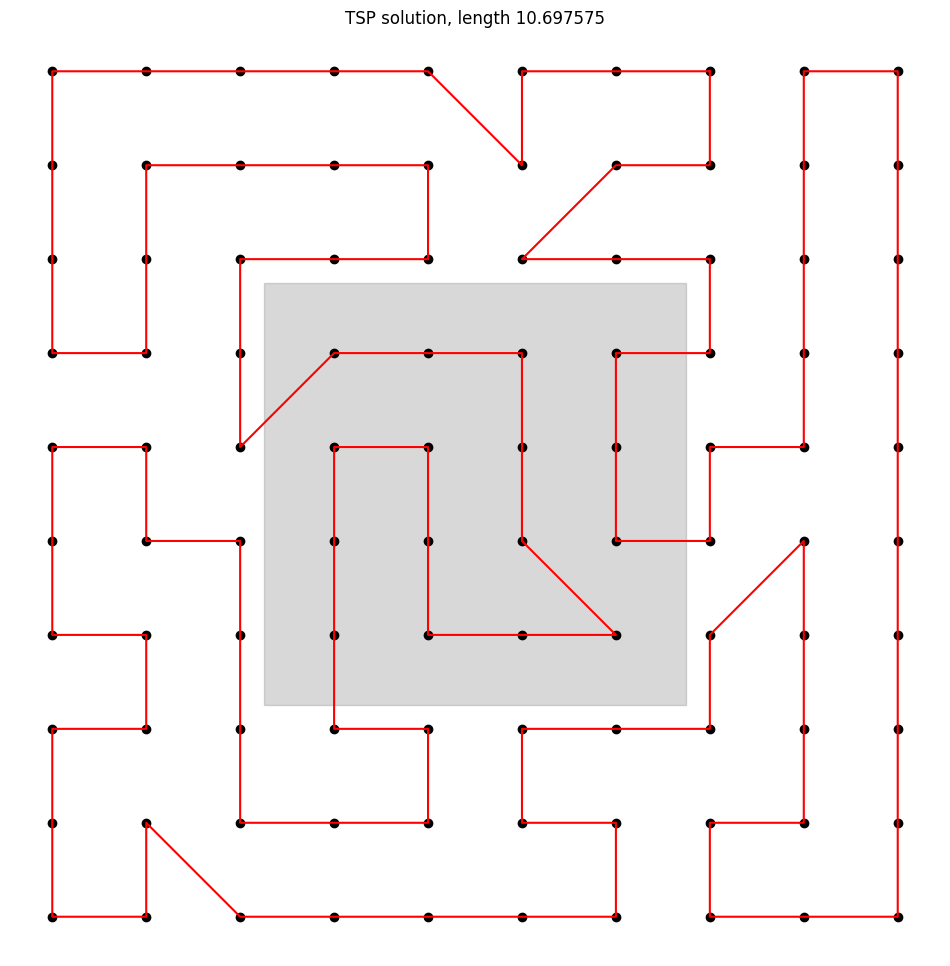

[97 87 86 75 76 77 67 66 56 46 47 57 58 68 78 88 98 99 89 79 69 59 49 39
 29 19  9  8  7 17 18 28 38 48 37 27 26 25 15 16  6  5  4  3  2 11  1  0
 10 20 21 31 30 40 50 51 41 42 32 22 12 13 14 24 23 33 43 53 54 44 34 35
 36 45 55 65 64 63 52 62 72 73 74 84 83 82 81 71 61 60 70 80 90 91 92 93
 94 85 95 96]


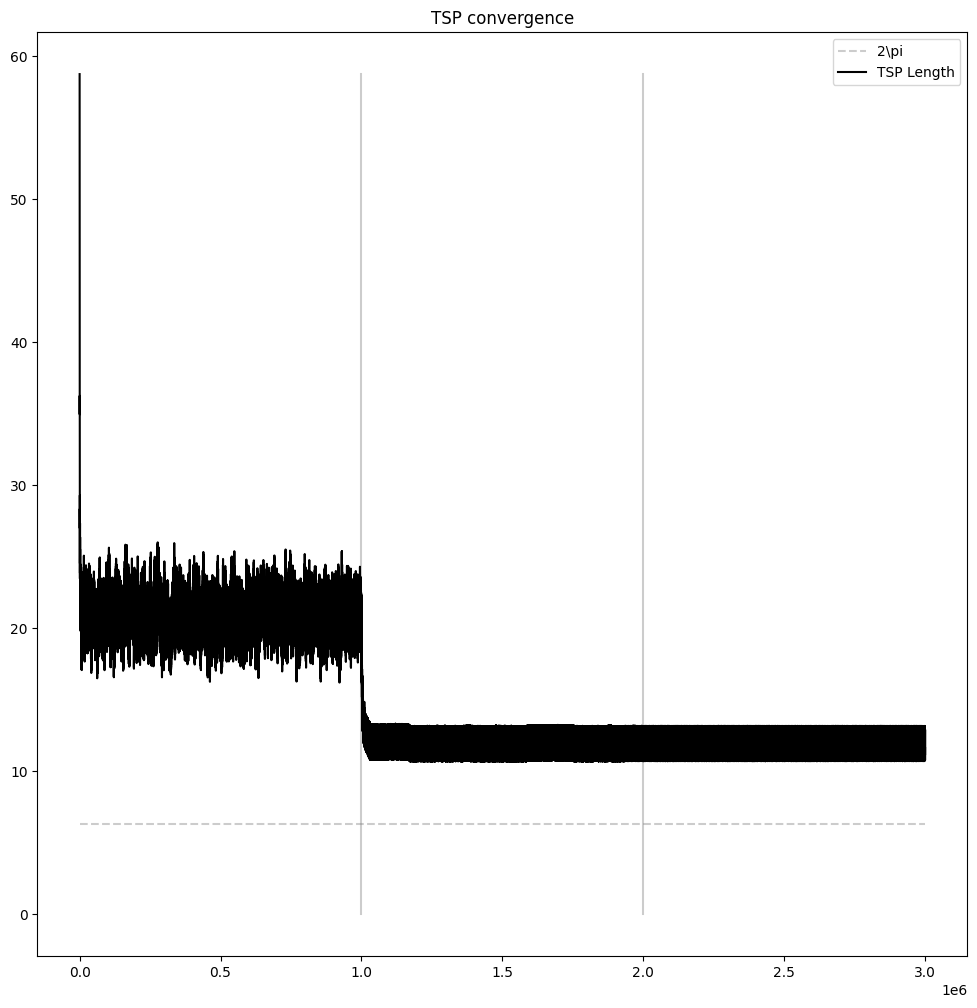

In [35]:
# try time dependent TSP on random points in unit square
simulated_annealing_time_dependent(nodes=nodes)